In [14]:
"""
LightGBM Binary Classifier
- Hyperparameter tuning với Optuna TPE (metric: Gini trên CV folds)
- KFold Cross Validation (k=5, stratified)
- Fit lại trên full train với best params
- Lưu model pkl, load lại để predict train & test
- Lưu cả train pred + test pred (với cột flag_train_test)
- Chỉ vẽ SHAP Beeswarm plot
"""

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import shap
import pickle
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 0. Config ──────────────────────────────────────────────────────────────────
DATA_PATH   = "master_data_train_test_split.csv"
ID_COL      = "SK_ID_CURR"
TARGET_COL  = "TARGET"
DATASET_COL = "flag_train_test"          # giá trị: "train" / "test"
FT_PATH     = r"D:\KL-lieuvth2\feature_shortlist.csv"
RANDOM_SEED = 42
N_SPLITS    = 5                # số folds KFold
N_TRIALS    = 50               # số lần Optuna thử
MODEL_PATH  = "lgbm_model.pkl"

In [15]:
# ── 1. Load data ───────────────────────────────────────────────────────────────
print("=" * 60)
print("1. Loading data …")
df = pd.read_csv(DATA_PATH).iloc[:, 1:]
print(f"   Shape: {df.shape}")
print(f"   dataset counts:\n{df[DATASET_COL].value_counts()}")

# ── 2. Split train / test ──────────────────────────────────────────────────────
train_df = df[df[DATASET_COL] == "train"].copy()
test_df  = df[df[DATASET_COL] == "test"].copy()

# Read selected features from FT_PATH
feature_list = pd.read_csv(FT_PATH)["feature"].dropna().astype(str).tolist()

# Chỉ giữ các feature thực sự tồn tại trong df
feature_cols = [c for c in feature_list if c in df.columns]

# Kiểm tra feature trong file nhưng không có trong df
missing_features = [c for c in feature_list if c not in df.columns]

print(f"\n2. Features selected from FT_PATH: {len(feature_cols)}")
print(f"   First 5 features: {feature_cols[:5]}")

if missing_features:
    print(f"   Warning: {len(missing_features)} features not found in df")
    print(f"   Missing: {missing_features[:10]}")

# Chỉ lấy các cột cần thiết
train_df = train_df[[ID_COL, TARGET_COL] + feature_cols].copy()
test_df  = test_df[[ID_COL, TARGET_COL] + feature_cols].copy()

# ── 3. Convert object → categorical ───────────────────────────────────────────
print("\n3. Converting object columns to categorical …")
for col in feature_cols:
    if df[col].dtype == "object":
        train_df[col] = train_df[col].astype("category")
        test_df[col]  = test_df[col].astype("category")
        print(f"   → {col}")

X_all  = train_df[feature_cols]
y_all  = train_df[TARGET_COL]
X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL] if TARGET_COL in test_df.columns else None

1. Loading data …
   Shape: (307511, 259)
   dataset counts:
flag_train_test
train    215257
test      92254
Name: count, dtype: int64

2. Features selected from FT_PATH: 76
   First 5 features: ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EMPLOY_YEARS', 'BUREAU_DEBT_CREDIT_RATIO', 'AMT_GOODS_PRICE']

3. Converting object columns to categorical …
   → ORGANIZATION_TYPE_GROUPED
   → NAME_INCOME_TYPE
   → NAME_EDUCATION_TYPE
   → NAME_FAMILY_STATUS
   → NAME_HOUSING_TYPE
   → NAME_CONTRACT_TYPE


In [16]:
# ── 4. Hàm Gini ───────────────────────────────────────────────────────────────
def gini(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) - 1

# ── 5. Optuna TPE tuning với KFold CV (k=5) ────────────────────────────────────
print("\n5. Optuna TPE tuning với StratifiedKFold (k=5) …")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

def objective(trial: optuna.Trial) -> float:
    params = {
        "objective":        "binary",
        "metric":           "auc",
        "verbosity":        -1,
        "boosting_type":    "gbdt",
        "random_state":     RANDOM_SEED,
        "n_estimators":     trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples":trial.suggest_int("min_child_samples", 1000, 3000),
        "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.7),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1.0, 10.0, log=True),
    }

    n_est = params.pop("n_estimators")
    cv_ginis = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
        X_tr, X_val = X_all.iloc[tr_idx], X_all.iloc[val_idx]
        y_tr, y_val = y_all.iloc[tr_idx], y_all.iloc[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr, free_raw_data=False)
        dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain, free_raw_data=False)

        model = lgb.train(
            params,
            dtrain,
            num_boost_round=n_est,
            valid_sets=[dvalid],
            callbacks=[lgb.log_evaluation(period=-1)],
        )

        preds = model.predict(X_val)
        fold_gini = gini(y_val, preds)
        cv_ginis.append(fold_gini)

    mean_gini = np.mean(cv_ginis)

    try:
        best_so_far = study.best_value
    except (ValueError, NameError):
        best_so_far = mean_gini

    param_str = " | ".join([
        f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}"
        for k, v in {**params, "n_estimators": n_est}.items()
        if k not in ("objective", "metric", "verbosity", "boosting_type", "random_state")
    ])

    print(
        f"Trial {trial.number:>3d} | "
        f"CV Gini (mean): {mean_gini:.6f} | "
        f"Folds: {[round(g, 4) for g in cv_ginis]} | "
        f"Best: {best_so_far:.6f}\n"
        f"   └─ {param_str}\n"
    )

    return mean_gini

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study   = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print(f"\n   ✓ Best CV Gini: {study.best_value:.6f}")
print(f"   Best params: {study.best_params}")


5. Optuna TPE tuning với StratifiedKFold (k=5) …
Trial   0 | CV Gini (mean): 0.551905 | Folds: [np.float64(0.5651), np.float64(0.5454), np.float64(0.5452), np.float64(0.5538), np.float64(0.55)] | Best: 0.551905
   └─ learning_rate=0.0722 | max_depth=5 | num_leaves=44 | min_child_samples=1312 | subsample=0.6468 | colsample_bytree=0.3232 | reg_lambda=7.3481 | n_estimators=437

Trial   1 | CV Gini (mean): 0.545966 | Folds: [np.float64(0.5578), np.float64(0.5383), np.float64(0.5397), np.float64(0.5457), np.float64(0.5483)] | Best: 0.551905
   └─ learning_rate=0.0436 | max_depth=3 | num_leaves=62 | min_child_samples=2665 | subsample=0.6637 | colsample_bytree=0.3727 | reg_lambda=1.5255 | n_estimators=641

Trial   2 | CV Gini (mean): 0.538151 | Folds: [np.float64(0.5495), np.float64(0.5323), np.float64(0.5314), np.float64(0.5374), np.float64(0.5402)] | Best: 0.551905
   └─ learning_rate=0.0298 | max_depth=4 | num_leaves=29 | min_child_samples=2224 | subsample=0.6418 | colsample_bytree=0.4169

In [17]:
# ── 6. Fit mô hình trên full train với best params ────────────────────────────
print("\n6. Re-fitting on full train set …")

final_params = {
    "objective":     "binary",
    "metric":        "auc",
    "verbosity":     -1,
    "boosting_type": "gbdt",
    "random_state":  RANDOM_SEED,
    **study.best_params,
}

n_estimators = final_params.pop("n_estimators", None)
if n_estimators is None:
    raise ValueError("Không tìm thấy 'n_estimators' trong study.best_params!")

dall = lgb.Dataset(X_all, label=y_all, free_raw_data=False)

final_model = lgb.train(
    final_params,
    dall,
    num_boost_round=n_estimators,
    valid_sets=[dall],
    callbacks=[lgb.log_evaluation(period=100)],
)

print(f"\n   ✓ Hoàn tất Re-fit với {n_estimators} cây trên full train set!")


6. Re-fitting on full train set …
[100]	training's auc: 0.775
[200]	training's auc: 0.786939
[300]	training's auc: 0.794504
[400]	training's auc: 0.800333
[500]	training's auc: 0.805671
[600]	training's auc: 0.810171
[700]	training's auc: 0.814039
[800]	training's auc: 0.817312
[900]	training's auc: 0.820288

   ✓ Hoàn tất Re-fit với 999 cây trên full train set!


In [18]:
# ── 7. Lưu model pkl ──────────────────────────────────────────────────────────
print(f"\n7. Saving model → {MODEL_PATH} …")
with open(MODEL_PATH, "wb") as f:
    pickle.dump(final_model, f)
print(f"   ✓ Saved → {MODEL_PATH}")


7. Saving model → lgbm_model.pkl …
   ✓ Saved → lgbm_model.pkl


In [19]:
# ── 8. Load lại model từ pkl → predict train & test ───────────────────────────
print(f"\n8. Loading model from {MODEL_PATH} …")
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)
print("   ✓ Model loaded OK")

# ── Predict train ──────────────────────────────────────────────────────────────
print("\n   Predicting on TRAIN set …")
y_pred_train = loaded_model.predict(X_all)
train_auc    = roc_auc_score(y_all, y_pred_train)
train_gini   = 2 * train_auc - 1
print(f"   Train AUC  : {train_auc:.6f}")
print(f"   Train Gini : {train_gini:.6f}")

# ── Predict test ───────────────────────────────────────────────────────────────
print("\n   Predicting on TEST set …")
y_pred_test = loaded_model.predict(X_test)

if y_test is not None and y_test.notna().all():
    test_auc  = roc_auc_score(y_test, y_pred_test)
    test_gini = 2 * test_auc - 1
    print(f"   Test AUC   : {test_auc:.6f}")
    print(f"   Test Gini  : {test_gini:.6f}")
else:
    print("   (Test labels không có sẵn – bỏ qua tính Gini trên test)")

# ── 9. Gộp & lưu predictions (train + test) với cột flag_train_test ───────────
print("\n9. Saving predictions …")

train_pred_df = train_df[[ID_COL, TARGET_COL]].copy()
train_pred_df["PRED_PROBA"]  = y_pred_train
train_pred_df[DATASET_COL]   = "train"

test_pred_df = test_df[[ID_COL, TARGET_COL]].copy()
test_pred_df["PRED_PROBA"]   = y_pred_test
test_pred_df[DATASET_COL]    = "test"

all_pred_df = pd.concat([train_pred_df, test_pred_df], ignore_index=True)
all_pred_df.to_csv("lgbm_pred.csv", index=False)
print(f"   ✓ Saved → lgbm_pred.csv  (shape: {all_pred_df.shape})")
print(f"   Breakdown:\n{all_pred_df[DATASET_COL].value_counts()}")


8. Loading model from lgbm_model.pkl …
   ✓ Model loaded OK

   Predicting on TRAIN set …
   Train AUC  : 0.823237
   Train Gini : 0.646474

   Predicting on TEST set …
   Test AUC   : 0.781172
   Test Gini  : 0.562344

9. Saving predictions …
   ✓ Saved → lgbm_pred.csv  (shape: (307511, 4))
   Breakdown:
flag_train_test
train    215257
test      92254
Name: count, dtype: int64



10. Computing SHAP values …


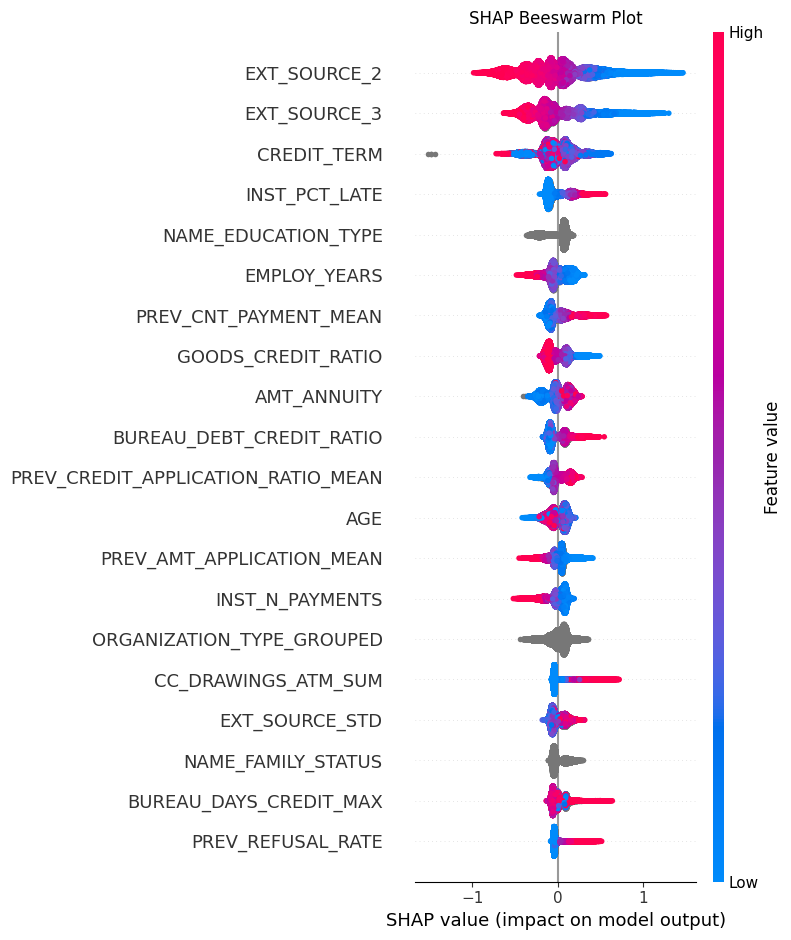

   ✓ Saved → shap_summary_beeswarm.png
   ✓ Saved → shap_importance.csv

Top 10 features by SHAP:
                 feature  mean_abs_shap
            EXT_SOURCE_2       0.314877
            EXT_SOURCE_3       0.256563
             CREDIT_TERM       0.146510
           INST_PCT_LATE       0.118681
     NAME_EDUCATION_TYPE       0.110665
            EMPLOY_YEARS       0.108336
   PREV_CNT_PAYMENT_MEAN       0.106750
      GOODS_CREDIT_RATIO       0.106612
             AMT_ANNUITY       0.106340
BUREAU_DEBT_CREDIT_RATIO       0.103471

Done!


In [20]:
# ── 10. SHAP Beeswarm Plot ────────────────────────────────────────────────────
print("\n10. Computing SHAP values …")

explainer   = shap.TreeExplainer(loaded_model)
shap_values = explainer.shap_values(X_test)

# — Beeswarm plot (duy nhất) —
plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("   ✓ Saved → shap_summary_beeswarm.png")

# — Lưu mean |SHAP| per feature —
shap_df = pd.DataFrame({
    "feature":       feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
shap_df.to_csv("shap_importance.csv", index=False)
print("   ✓ Saved → shap_importance.csv")

print("\nTop 10 features by SHAP:")
print(shap_df.head(10).to_string(index=False))

print("\n" + "=" * 60)
print("Done!")